In [13]:
import collections
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from PIL import Image
from wordcloud import WordCloud
import nltk
nltk.download(["stopwords","vader_lexicon","punkt","wordnet"])
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer
from numpy import asarray
from pathlib import Path

DATA_DIR = Path("../data")
df = pd.read_csv(DATA_DIR / "processed/lyrics_clean.csv")

df.shape

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ryanhoffman/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/ryanhoffman/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/ryanhoffman/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/ryanhoffman/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


(65, 8)

In [16]:
# Creating stopword list from nlkt
stop_words = stopwords.words('english')

#extending stopword list
stop_words.extend(['or', 'm', 'ma', 'ours', 'against', 'nor', "it's", 'o', 
'wasn', 'hasn', 'my', 'had', 'didn', 'isn', 'did', 'aren', 'those', 'than', 
"mustn't", "you've", 'to', 'she', 'having', "haven't", 'into', 't', 'll', 
'himself', 'do', "that'll", 'so', 'of', 'on', 'very', 'for', 'out', 'were', 
'should', 'they', 'ain', "should've", 'you', "didn't", 'yours', 'was', 'our',
 'can', 'myself', "shouldn't", 'have', 'up', 'mightn', "you'll", 'any', 
'itself', 'hadn', 'him', 'doesn', 'weren', 'y', 'being', "don't", 'them', 
'are','and', 'that', 'your', 'yourself', 'their', 'some', 'ourselves', 've', 
'doing', 'been', 'shouldn', 'yourselves', "mightn't", 'most', 'because',
 'few', 'wouldn', "you'd", 'through', "you're", 'themselves', 'an', 'if',
 "wouldn't", 'its', 'other', "won't", "wasn't", "she's", 'we', 'shan',
 "weren't",'don',"hadn't", 'this', 'off', 'while', 'a', 'haven', 'her', 
'theirs', 'all', "hasn't", "doesn't", 'about', 'then', 'by','such', 'but', 
'until', 'each', 'there', "aren't", 'with', 'not', "shan't", 'hers', 'it', 
'too', 'i', 'at', 'is', 'as', 'me', 'herself', 's', 'the', 'where', 'am', 
'has', 'over', "couldn't", 'when', 'does', 'mustn','re', 'no', 'in', 'who', 
'd', 'own', 'he', 'be', "isn't", 'his', 'these', 'same', 'whom', 'will', 
'needn','couldn', 'from'])

In [17]:
def preprocess_text(text):
    # Tokenise words & ignore punctuation
    tokeniser = RegexpTokenizer(r'\w+')
    tokens = tokeniser.tokenize(text)
    
    data_token=[token.lower() for token in tokens]
    processed_words= [w for w in data_token if not w in stop_words]
    return processed_words

In [19]:
#saving normalized text in new variable cleaned_text
cleaned_text = []

for song in df["lyrics_clean"].to_list():
    cleaned_text.extend(preprocess_text(song))

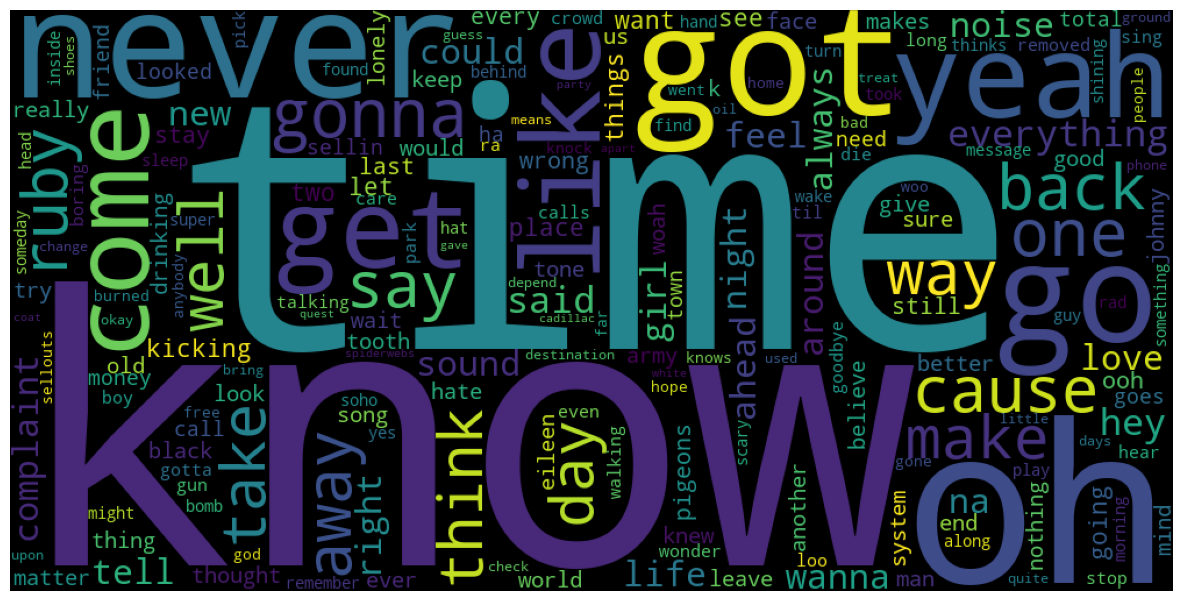

In [ ]:
#convert list to string and generate 1st Wordcloud

word_cloud_dict = Counter(cleaned_text)

wordcloud = WordCloud(
    background_color="black",
    width=1000,
    height=500,
    collocations=False,
    random_state=100,
    stopwords=stop_words
).generate_from_frequencies(word_cloud_dict)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()


In [27]:
# I probably need to do this with a bunch of popular albums. It feels like I need way more songs for the sake of a word cloud
# I wonder what the best way to get song lyrics from albums is